##Imports

In [17]:
!pip install -q lime

In [18]:
import os
import numpy as np
import pandas as pd
import joblib
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
from scipy.special import softmax
import random

In [19]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

##Load Dataset

In [20]:
TEST_PATH = "./final_submission/test.csv"
CLASSES_PATH = "./final_submission/classes.txt"

test_df = pd.read_csv(TEST_PATH, header=None, names=["label","title","text"])
test_df["text"] = test_df["title"].fillna("").astype(str) + ". " + test_df["text"].fillna("").astype(str)
test_df = test_df[test_df["text"].str.strip().astype(bool)]

with open(CLASSES_PATH, "r") as f:
    class_names = [line.strip() for line in f]


In [21]:
# Normalize labels for test data
if test_df["label"].max() > 13:
    test_df["label"] -= 1


##Load TF-IDF + SVM Baseline

In [22]:
svm_model_path = "./final_submission/tfidf_svm_baseline.pkl"
svm_baseline = joblib.load(svm_model_path)

print("Loaded TF-IDF + SVM baseline.")


Loaded TF-IDF + SVM baseline.


##Evaluate SVM Baseline

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      5000
           1       0.99      0.99      0.99      5000
           2       0.97      0.97      0.97      5000
           3       1.00      0.99      1.00      5000
           4       0.98      0.98      0.98      5000
           5       0.99      0.99      0.99      5000
           6       0.98      0.98      0.98      5000
           7       0.99      1.00      0.99      5000
           8       1.00      1.00      1.00      5000
           9       0.99      0.99      0.99      5000
          10       0.99      0.99      0.99      5000
          11       0.99      0.99      0.99      5000
          12       0.99      0.99      0.99      5000
          13       0.98      0.98      0.98      5000

    accuracy                           0.99     70000
   macro avg       0.99      0.99      0.99     70000
weighted avg       0.99      0.99      0.99     70000

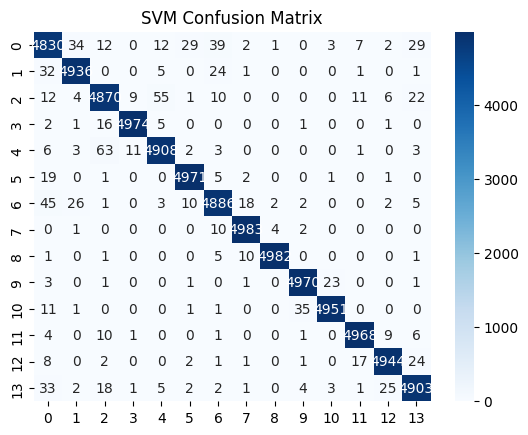

In [23]:
svm_preds = svm_baseline.predict(test_df["text"].tolist())

print("SVM Classification Report:")
print(classification_report(test_df["label"], svm_preds))

cm = confusion_matrix(test_df["label"], svm_preds)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("SVM Confusion Matrix")
plt.show()


##Load the Fine-Tuned DistilBERT Model

In [24]:
bert_model_dir = "./final_submission/bert_model"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(bert_model_dir)
model = AutoModelForSequenceClassification.from_pretrained(bert_model_dir)
model.to(device)
model.eval()

print("Loaded BERT model.")


Loaded BERT model.


##Prepare Test Data for BERT Evaluation

In [25]:
def encode(texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128, return_tensors="pt")


##Evaluate BERT Model

BERT Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5000
           1       0.99      0.99      0.99      5000
           2       0.98      0.99      0.99      5000
           3       1.00      1.00      1.00      5000
           4       0.99      0.99      0.99      5000
           5       0.99      1.00      1.00      5000
           6       0.99      0.98      0.99      5000
           7       1.00      1.00      1.00      5000
           8       1.00      1.00      1.00      5000
           9       1.00      1.00      1.00      5000
          10       1.00      1.00      1.00      5000
          11       1.00      1.00      1.00      5000
          12       1.00      0.99      1.00      5000
          13       0.99      0.99      0.99      5000

    accuracy                           0.99     70000
   macro avg       0.99      0.99      0.99     70000
weighted avg       0.99      0.99      0.99     7000

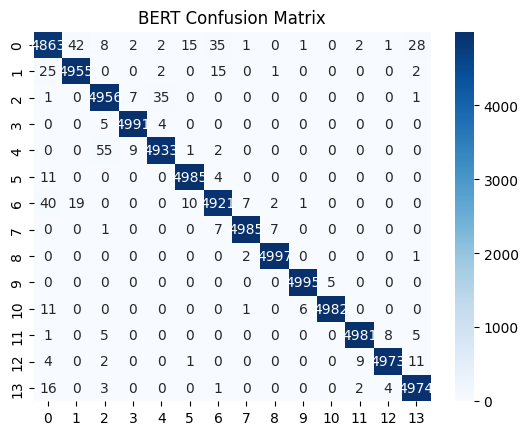

In [26]:
all_preds = []
all_labels = test_df["label"].tolist()

batch_size = 32
texts = test_df["text"].tolist()

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    enc = encode(batch)
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
        preds = logits.argmax(dim=1).cpu().numpy()

    all_preds.extend(preds)

print("BERT Classification Report:")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("BERT Confusion Matrix")
plt.show()


##Compare Models

In [27]:
svm_acc = accuracy_score(test_df["label"], svm_preds)
bert_acc = accuracy_score(all_labels, all_preds)

svm_f1 = f1_score(test_df["label"], svm_preds, average="weighted")
bert_f1 = f1_score(all_labels, all_preds, average="weighted")

results = pd.DataFrame({
    "Model": ["TF-IDF + SVM", "DistilBERT"],
    "Accuracy": [svm_acc, bert_acc],
    "F1-weighted": [svm_f1, bert_f1]
})

print(results)


          Model  Accuracy  F1-weighted
0  TF-IDF + SVM  0.986800     0.986799
1    DistilBERT  0.992729     0.992725


##LIME Explanation

In [28]:
with open(CLASSES_PATH, "r") as f:
    class_names = [line.strip() for line in f]

# LIME Explainer for text classification
explainer = LimeTextExplainer(class_names=class_names)

###BERT prediction function required by LIME

In [29]:
def predict_proba_for_bert(texts):
    model.eval()
    batch_size = 16
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True,
                        truncation=True, max_length=128)
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()

        all_probs.append(probs)

    return np.vstack(all_probs)

###SVM prediction function for LIME

In [30]:
def predict_proba_for_svm(texts):
    decision_scores = svm_baseline.decision_function(texts)
    probs = softmax(decision_scores, axis=1)
    return probs

###Select a random sample from the test set for LIME

In [36]:
sample_idx = random.randrange(len(test_df))

sample_text = test_df.iloc[sample_idx]["text"]
true_label = test_df.iloc[sample_idx]["label"]

print(f"\nRandom Sample Index: {sample_idx}")
print("Sample Text:", sample_text[:400], "...")
print("True Label:", class_names[true_label])


Random Sample Index: 36048
Sample Text: Fresvikbreen.  Fresvikbreen is a glacier on the south side of the Sognefjord in the municipality of Vik in Sogn og Fjordane county Norway. It lies between the Seljedal valley in the west and the Storedal valley in the east. It is 9 kilometres (5.6 mi) southwest of the village of Fresvik and 11 kilometres (6.8 mi) southeast of the municipal center of Vikøyri.The glacier has an area of 15 square kil ...
True Label: NaturalPlace


##LIME for BERT

 LIME EXPLANATION SAMPLE

 To visualize the behavior of both models, we randomly pick
 a single test instance and generate LIME explanations for it.

 LIME takes the input text and identifies which words had
 the strongest positive or negative influence on the predicted
 class. This provides a local explanation of each model’s
 decision-making process.

 Comparing LIME outputs for BERT and SVM helps illustrate how
 the two models rely on different lexical cues to classify the
 same document.



**How to Read the LIME Plots:**

Each LIME plot shows which words in the text influenced the model’s prediction.

* Green bars = words that support the predicted class

* Red bars = words that push against the predicted class

* Longer bars = stronger influence

For BERT:
BERT usually focuses on a few very meaningful words. You’ll often see one or two strong green bars that clearly point to why it chose a class.

For SVM:
The SVM model spreads its attention across many words. It relies on word frequency patterns, so it often shows several medium-sized bars instead of one strong one.

These plots help compare how each model “reasons” about the same text.

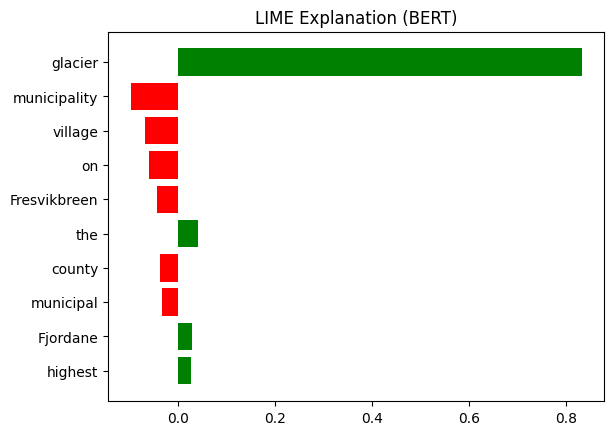

Saved BERT LIME explanation to: ./final_submission/bert_lime_sample.html


In [39]:
exp_bert = explainer.explain_instance(
    sample_text,
    predict_proba_for_bert,
    top_labels=2
)

# Visualize
exp_bert.as_pyplot_figure(label=exp_bert.top_labels[0])
plt.title("LIME Explanation (BERT)")
plt.show()

# Save HTML
bert_lime_path = "./final_submission/bert_lime_sample.html"
with open(bert_lime_path, "w") as f:
    f.write(exp_bert.as_html())

print("Saved BERT LIME explanation to:", bert_lime_path)

##LIME for SVM

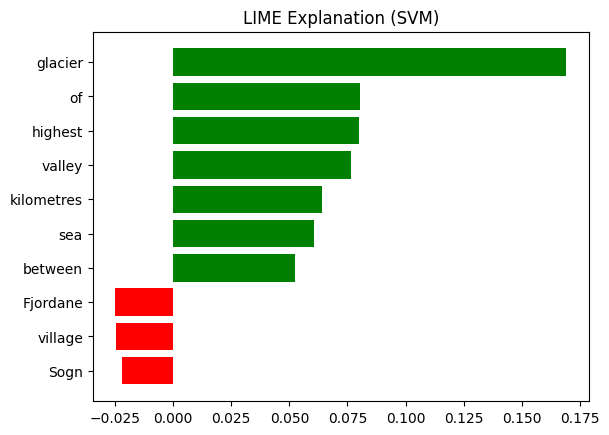

Saved SVM LIME explanation to: ./final_submission/svm_lime_sample.html


In [38]:
exp_svm = explainer.explain_instance(
    sample_text,
    predict_proba_for_svm,
    top_labels=2
)

# Visualize
exp_svm.as_pyplot_figure(label=exp_svm.top_labels[0])
plt.title("LIME Explanation (SVM)")
plt.show()

# Save HTML
svm_lime_path = "./final_submission/svm_lime_sample.html"
with open(svm_lime_path, "w") as f:
    f.write(exp_svm.as_html())

print("Saved SVM LIME explanation to:", svm_lime_path)

##Per-class performance comparison

In [34]:
svm_prf = precision_recall_fscore_support(test_df["label"], svm_preds, average=None, zero_division=0)
bert_prf = precision_recall_fscore_support(test_df["label"], all_preds, average=None, zero_division=0)

per_class_results = pd.DataFrame({
    "Class": class_names,
    "SVM_F1": svm_prf[2],
    "BERT_F1": bert_prf[2]
})

per_class_results


,Class,SVM_F1,BERT_F1
0,Company,0.965421,0.975331
1,EducationalInstitution,0.986411,0.989417
2,Artist,0.974487,0.987743
3,Athlete,0.995198,0.997302
4,OfficeHolder,0.982288,0.988974
5,MeanOfTransportation,0.992315,0.995805
6,Building,0.978472,0.985679
7,NaturalPlace,0.994710,0.997399
8,Village,0.997497,0.998701
9,Animal,0.992412,0.998700
